# Layer × layer R² heatmaps (pilot setup)

This notebook reproduces the **affine alignment heatmaps** from `data_analysis.py`, tailored to the **current repo checkout**:

- **Two agents** are the same backbone (or any pair you list): hidden states from **model A** at layer `i` are regressed onto **model B** at layer `j` (see `affine_transformation.py` for the exact forward/backward pairing).
- **50 episodes** per run (`experiment_config.EPISODES_NUM`) — affects how much data was used to fit each affine map, not the file naming here.
- **One simulation RNG seed** (`experiment_config.STAGE_A_SEEDS = [0]`) — JSON result files are named with a `[0]` suffix so they match `t0.7_seed0` state directories.

Each cell **loads precomputed** `allreps.json` files under `affine_transformation/<setting>/layerA*/data/` and plots **test R²** (mean over evaluation seeds inside that JSON) as a heatmap: **x = Model A layer**, **y = Model B layer**.

## Why not import `data_analysis.py` as-is?

The original `get_r2_results_single()` hardcodes the filename fragment **`[0, 1, 2, 3, 4]`** for the Stage A seed list. After switching affine training to `STAGE_A_SEEDS` from `experiment_config`, files look like **`..._Misv0.3Misv0.3[0]_layerA...`**. This notebook builds that suffix **from `STAGE_A_SEEDS`** so it stays in sync with simulation and affine scripts.

In [2]:
# --- Imports and repo root ---
# Run this notebook from the repo root or from playground/; both work.
import os
import sys
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Resolve LM_neural_synchrony root: playground/ contains its own utils.py, so we must not
# treat playground as the repo root. Require experiment_config.py next to the main utils.
_cwd = Path.cwd().resolve()
_repo = None
for candidate in (_cwd, _cwd.parent, _cwd.parent.parent):
    if (candidate / "experiment_config.py").is_file() and (candidate / "utils.py").is_file():
        _repo = candidate
        break
if _repo is None:
    raise FileNotFoundError(
        "Could not find repo root (need experiment_config.py + utils.py). "
        "Run the notebook with cwd = LM_neural_synchrony/ or playground/."
    )
sys.path.insert(0, str(_repo))

from experiment_config import EPISODES_NUM, STAGE_A_SEEDS
from utils import REPO_ROOT, get_short_names_and_identifiers

AFFINE_ROOT = os.path.join(REPO_ROOT, "affine_transformation")
FIG_DIR = os.path.join(REPO_ROOT, "playground", "figs_layer_r2_pilot")
os.makedirs(FIG_DIR, exist_ok=True)

print("REPO_ROOT:", REPO_ROOT)
print("Pilot: EPISODES_NUM =", EPISODES_NUM, "| STAGE_A_SEEDS =", STAGE_A_SEEDS)

REPO_ROOT: /juice6/u/jshe/nlp/LM_neural_synchrony
Pilot: EPISODES_NUM = 50 | STAGE_A_SEEDS = [0]


## Affine result file naming

For each pair `(layer_A, layer_B)`, affine training writes:

`affine_transformation/<setting>/layerA<layer_A>/data/<data_mode>_<id><seed_tag>_layerA<layer_A>_layerB<layer_B>_allreps.json`

- `<id>` is the short name from `get_short_names_and_identifiers`, e.g. `Misv0.3Misv0.3`.
- `<seed_tag>` is **`str(STAGE_A_SEEDS)`** from the affine run, e.g. `[0]`.
- Inside the JSON, keys are the same short names; values contain `r2_mean` (list with one entry per affine **random seed** in the outer loop — typically `(0,1,2)` in `linear_all_reps_layer_by_layer`).

In [3]:
DATA_MODE = "combined_metrics"


def seed_tag():
    """Must match affine_transformation.py: models_identifier += str(seed_list)"""
    return str(list(STAGE_A_SEEDS))


def get_layer_range_for_model(model_name: str):
    """Same rule as data_analysis.get_layer_range (e.g. Llama-3.2-3B → 28 layers)."""
    if "3B" in model_name:
        return (0, 27)
    return (0, 31)


def models_identifier_from_pair(model_1: str, model_2: str) -> str:
    """Single pair folder id, e.g. Misv0.3Misv0.3 — same as affine_transformation."""
    combined = f"{model_1}_{model_2}"
    _, mid = get_short_names_and_identifiers([combined])
    return mid + seed_tag()


def r2_json_path(setting: str, layer_a: int, layer_b: int, models_id: str) -> str:
    """Absolute path to one layer-pair result file."""
    fname = f"{DATA_MODE}_{models_id}_layerA{layer_a}_layerB{layer_b}_allreps.json"
    return os.path.join(AFFINE_ROOT, setting, f"layerA{layer_a}", "data", fname)


def load_r2_mean_for_pair(path: str, key: str) -> float:
    """Read test R² mean (first element) for the short-name key in the JSON."""
    with open(path, "r") as f:
        data = json.load(f)
    if key not in data:
        raise KeyError(f"Key {key!r} not in {path}; have {list(data.keys())}")
    return float(data[key]["r2_mean"][0])


def build_r2_grid(model_1: str, model_2: str, setting: str):
    """
    Fill a 2D array grid[i,j] = R² for (layer_A=i, layer_B=j) under `setting`.

    For A_forward: rows/cols follow affine convention — model_1 is "A", model_2 is "B" in the setting name.
    Layer ranges follow the first model's width for A and second for B when setting starts with A;
    see get_r2_scores_setting in data_analysis.py for the swap on B_forward.
    """
    if setting.startswith("A"):
        ra = get_layer_range_for_model(model_1)
        rb = get_layer_range_for_model(model_2)
    else:
        # B_forward: layer A axis is model_2, layer B axis is model_1 in the original code
        ra = get_layer_range_for_model(model_2)
        rb = get_layer_range_for_model(model_1)

    layers_a = list(range(ra[0], ra[1] + 1))
    layers_b = list(range(rb[0], rb[1] + 1))
    combined = f"{model_1}_{model_2}"
    short_names, _ = get_short_names_and_identifiers([combined])
    json_key = short_names[0]
    models_id = models_identifier_from_pair(model_1, model_2)

    grid = np.full((len(layers_a), len(layers_b)), np.nan, dtype=float)
    for ia, la in enumerate(layers_a):
        for ib, lb in enumerate(layers_b):
            p = r2_json_path(setting, la, lb, models_id)
            if not os.path.isfile(p):
                continue
            try:
                grid[ia, ib] = load_r2_mean_for_pair(p, json_key)
            except Exception as e:
                print(f"WARN {p}: {e}")
    return grid, json_key, models_id


def plot_r2_heatmap(
    grid: np.ndarray,
    title: str,
    save_name: str,
    vmin: float = 0.0,
    vmax: float = 1.0,
) -> None:
    """
    Match data_analysis.plot_heatmap: Greens for nonnegative, gray mask for negative,
    black rectangle on each column's argmax (after flip for image coordinates).
    """
    # grid indexed [layer_A, layer_B]; heatmap shows Model A on x, Model B on y
    data = grid.T
    flipped = np.flipud(data)
    n, m = flipped.shape

    plt.figure(figsize=(10, 10))
    # Mask invalid or negative cells (original also overlays gray for negatives)
    mask_plot = np.isnan(flipped) | (flipped < 0)
    ax = sns.heatmap(
        flipped,
        cmap="Greens",
        vmin=vmin,
        vmax=vmax,
        mask=mask_plot,
        square=False,
    )
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=18)
    ax.set_xlabel("Model A layer", fontsize=20)
    ax.set_ylabel("Model B layer", fontsize=20)
    ax.set_title(title, fontsize=16)
    ax.set_xticks(np.arange(0, n, 5) + 0.5)
    ax.set_xticklabels(np.arange(0, n, 5), fontsize=14)
    ax.set_yticks(np.arange(m - 1, -1, -5) + 0.5)
    ax.set_yticklabels(np.arange(0, m, 5), rotation=0, fontsize=14)

    valid = np.where(~np.isnan(flipped) & (flipped >= 0), flipped, np.nan)
    for j in range(flipped.shape[1]):
        col = valid[:, j]
        if np.all(np.isnan(col)):
            continue
        max_idx = int(np.nanargmax(col))
        ax.add_patch(
            plt.Rectangle((j, max_idx), 1, 1, linewidth=2, edgecolor="black", facecolor="none")
        )
    plt.tight_layout()
    out = os.path.join(FIG_DIR, save_name)
    plt.savefig(out, dpi=200)
    plt.show()
    print("Saved", out)

## Configure model pair

Use the **same** `model_1` / `model_2` strings as folder names under `sotopia_results/` (e.g. `Mistral-7B-Instruct-v0.3_None_0_...`).  
For a **single backbone** twice, both are the same full name.

In [4]:
# Example: same Mistral v0.3 for both agents (matches Misv0.3Misv0.3 keys in JSON)
MODEL_1 = "Mistral-7B-Instruct-v0.3_None_0"
MODEL_2 = "Mistral-7B-Instruct-v0.3_None_0"

pair_tag = f"{MODEL_1.split('_')[0][:4]}_{MODEL_2.split('_')[0][:4]}"  # optional short label for filenames only

### `A_forward`

Maps activations aligned with **agent A**’s stream at layer `layer_A` to **agent B** at `layer_B` (see `setting` in `get_all_states_interactive_with_boundaries`).

JSON key: Misv0.3Misv0.3 | file id prefix: Misv0.3Misv0.3[0]
Grid shape: (32, 32) nan count: 0


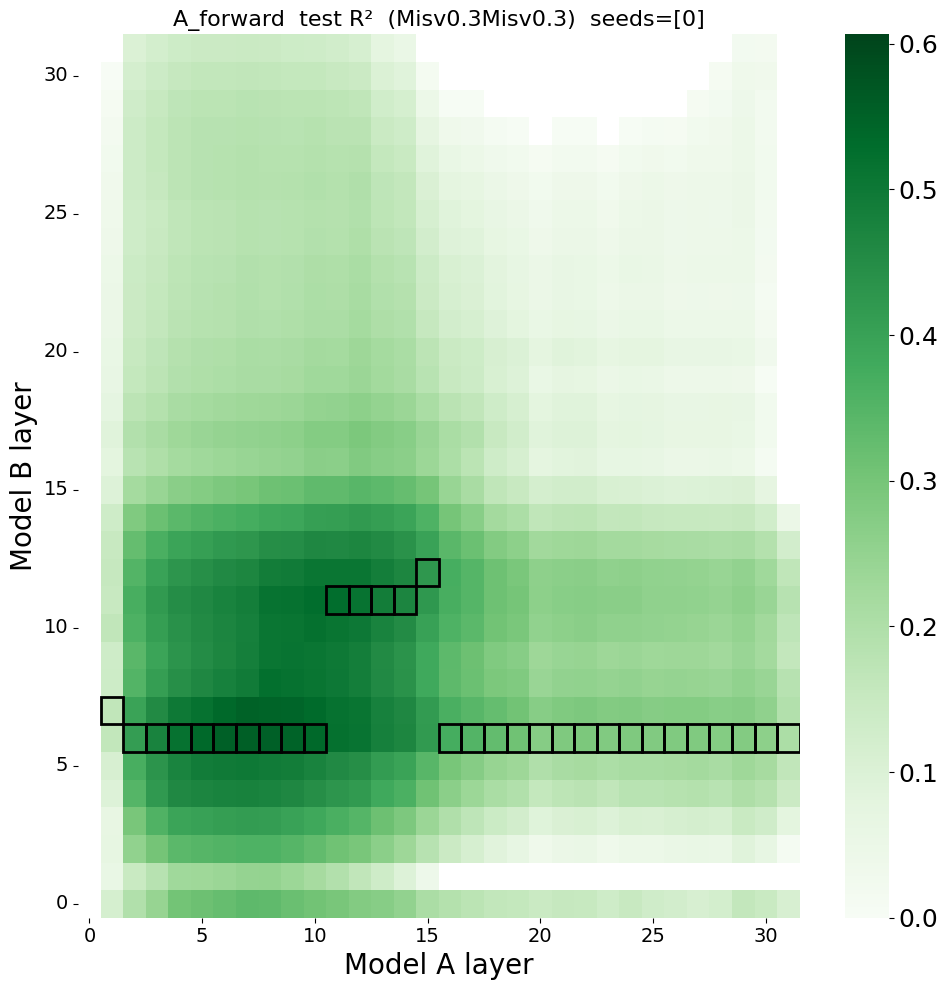

Saved /juice6/u/jshe/nlp/LM_neural_synchrony/playground/figs_layer_r2_pilot/A_forward_Misv0.3Misv0.3_r2_heatmap.pdf


In [5]:
grid_a, json_key, models_id = build_r2_grid(MODEL_1, MODEL_2, "A_forward")
print("JSON key:", json_key, "| file id prefix:", models_id)
print("Grid shape:", grid_a.shape, "nan count:", np.isnan(grid_a).sum())

plot_r2_heatmap(
    grid_a,
    title=f"A_forward  test R²  ({json_key})  seeds={STAGE_A_SEEDS}",
    save_name=f"A_forward_{json_key}_r2_heatmap.pdf",
    vmin=0.0,
    vmax=min(1.0, float(np.nanmax(grid_a)) + 0.05) if np.isfinite(np.nanmax(grid_a)) else 1.0,
)

### `B_forward`

Same machinery with `B_forward` setting (which agent’s turns are aligned first is swapped in the loader — layer axis assignment matches `data_analysis.get_r2_scores_setting` when `setting` starts with `B`).

JSON key: Misv0.3Misv0.3 | file id: Misv0.3Misv0.3[0]


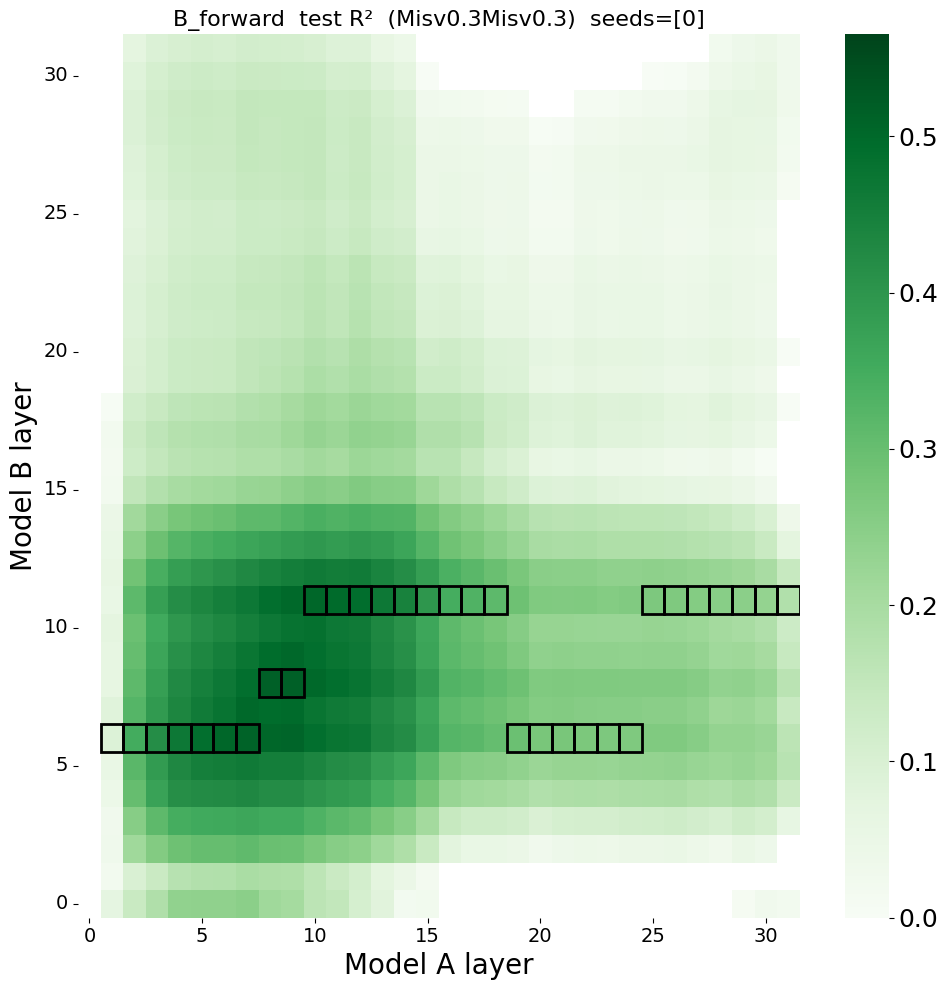

Saved /juice6/u/jshe/nlp/LM_neural_synchrony/playground/figs_layer_r2_pilot/B_forward_Misv0.3Misv0.3_r2_heatmap.pdf


In [6]:
grid_b, json_key_b, models_id_b = build_r2_grid(MODEL_1, MODEL_2, "B_forward")
print("JSON key:", json_key_b, "| file id:", models_id_b)

plot_r2_heatmap(
    grid_b,
    title=f"B_forward  test R²  ({json_key_b})  seeds={STAGE_A_SEEDS}",
    save_name=f"B_forward_{json_key_b}_r2_heatmap.pdf",
    vmin=0.0,
    vmax=min(1.0, float(np.nanmax(grid_b)) + 0.05) if np.isfinite(np.nanmax(grid_b)) else 1.0,
)

## Optional: cross-version Mistral pair

Uncomment and run if you have affine outputs for e.g. v0.3 vs v0.2 (folder names must match `sotopia_results`).

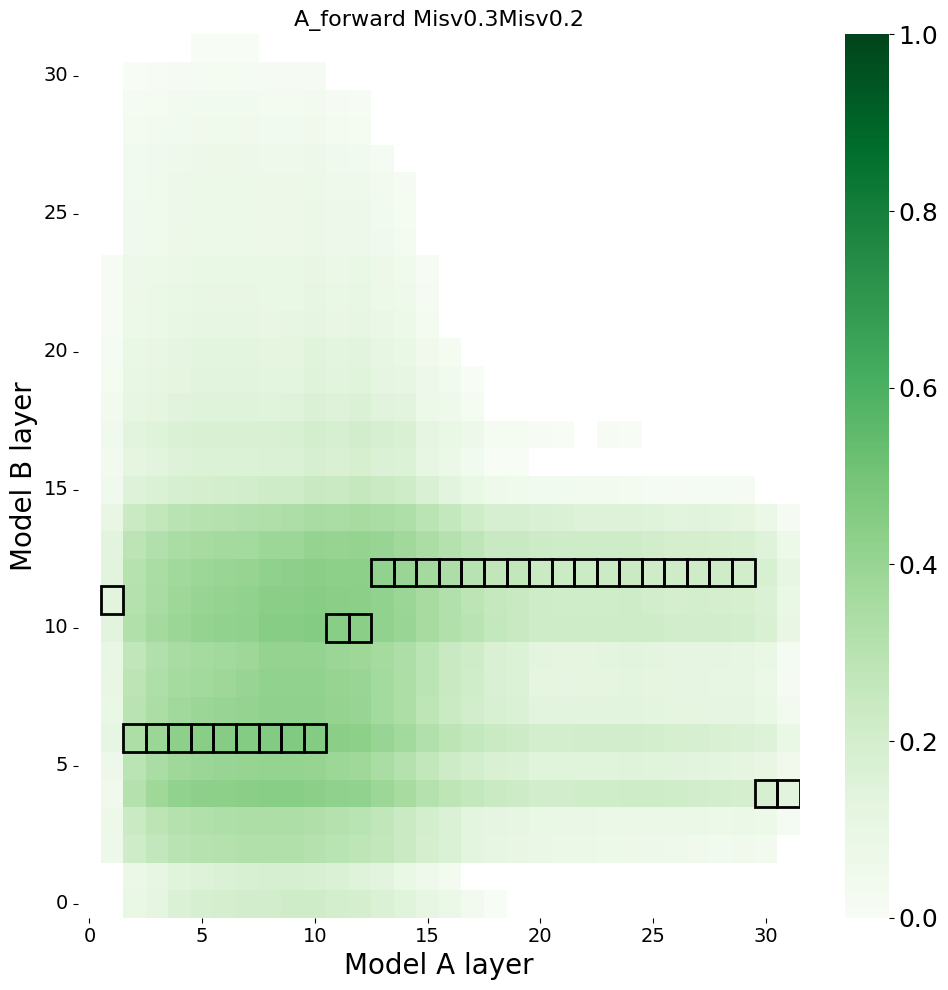

Saved /juice6/u/jshe/nlp/LM_neural_synchrony/playground/figs_layer_r2_pilot/A_forward_cross_Misv0.3Misv0.2.pdf


In [8]:
MODEL_1 = "Mistral-7B-Instruct-v0.3_None_0"
MODEL_2 = "Mistral-7B-Instruct-v0.2_None_0"
g, k, _ = build_r2_grid(MODEL_1, MODEL_2, "A_forward")
plot_r2_heatmap(g, f"A_forward {k}", f"A_forward_cross_{k}.pdf")

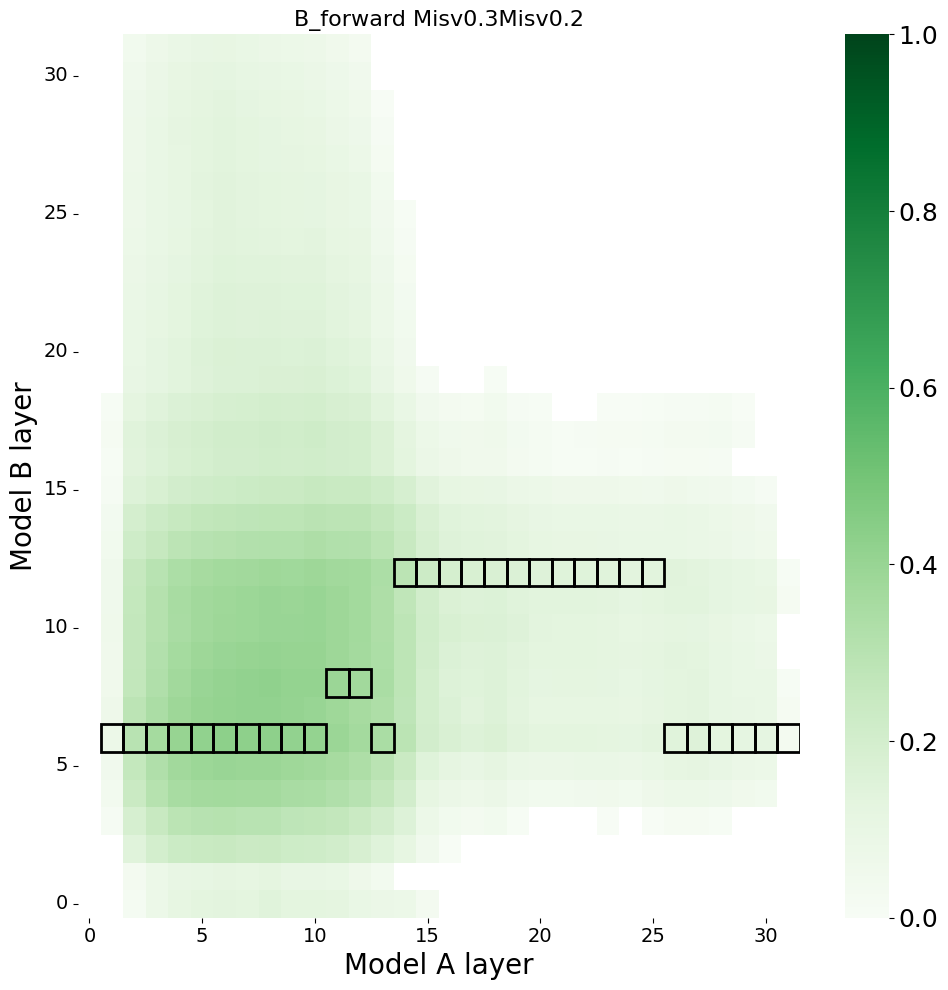

Saved /juice6/u/jshe/nlp/LM_neural_synchrony/playground/figs_layer_r2_pilot/B_forward_cross_Misv0.3Misv0.2.pdf


In [ ]:
g, k, _ = build_r2_grid(MODEL_1, MODEL_2, "B_forward")
plot_r2_heatmap(g, f"B_forward {k}", f"B_forward_cross_{k}.pdf")